In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import numpy as np
import tensorflow as tf
import pandas as pd
from tqdm import tqdm
import os
from cv2 import imread, createCLAHE
import cv2
from glob import glob
%matplotlib inline
import matplotlib.pyplot as plt

In [3]:
image_path = os.path.join("/content/drive/MyDrive/Major_Project_Pneumonia_Detection/D1/CXR_png")
mask_path = os.path.join("/content/drive/MyDrive/Major_Project_Pneumonia_Detection/D1/","masks/")

In [4]:
images = os.listdir(image_path)
mask = os.listdir(mask_path)
mask = [fName.split(".png")[0] for fName in mask]
image_file_name = [fName.split("_mask")[0] for fName in mask]

In [5]:
check = [i for i in mask if "mask" in i]
print("Total mask that has modified name:",len(check))

Total mask that has modified name: 566


In [6]:
testing_files = set(os.listdir(image_path)) & set(os.listdir(mask_path))
training_files = check

def getData(X_shape, flag="test"):
    im_array = []
    mask_array = []

    if flag == "test":
        for i in tqdm(testing_files):
            try:
                im = cv2.resize(cv2.imread(os.path.join(image_path, i)), (X_shape, X_shape))[:, :, 0]
                mask = cv2.resize(cv2.imread(os.path.join(mask_path, i)), (X_shape, X_shape))[:, :, 0]
                im_array.append(im)
                mask_array.append(mask)
            except Exception as e:
                print(f"Error processing {i}: {e}")

        return im_array, mask_array

    if flag == "train":
        for i in tqdm(training_files):
            try:
                im = cv2.resize(cv2.imread(os.path.join(image_path, i.split("_mask")[0] + ".png")),
                                (X_shape, X_shape))[:, :, 0]
                mask = cv2.resize(cv2.imread(os.path.join(mask_path, i + ".png")), (X_shape, X_shape))[:, :, 0]
                im_array.append(im)
                mask_array.append(mask)
            except Exception as e:
                print(f"Error processing {i}: {e}")

        return im_array, mask_array

In [7]:
#perform sanity check

def plotMask(X,y):
    sample = []

    for i in range(6):
        left = X[i]
        right = y[i]
        combined = np.hstack((left,right))
        sample.append(combined)


    for i in range(0,6,3):

        plt.figure(figsize=(25,10))

        plt.subplot(2,3,1+i)
        plt.imshow(sample[i])

        plt.subplot(2,3,2+i)
        plt.imshow(sample[i+1])


        plt.subplot(2,3,3+i)
        plt.imshow(sample[i+2])

        plt.show()

In [9]:
# Load training and testing data
dim = 256*2
X_train,y_train = getData(dim,flag="train")
X_test, y_test = getData(dim)

100%|██████████| 138/138 [03:00<00:00,  1.31s/it]


training set


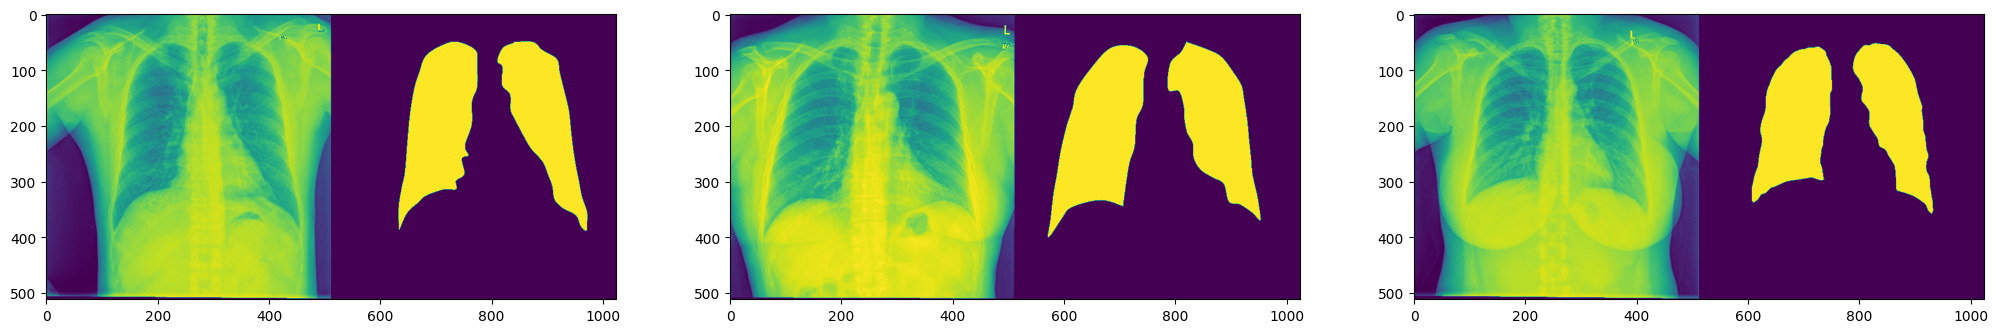

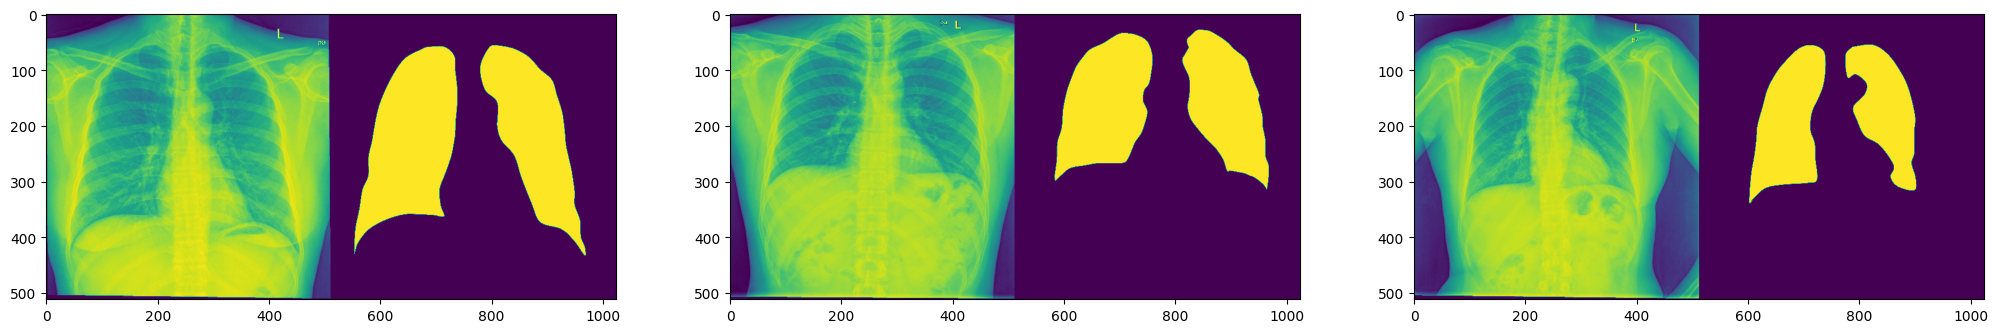

testing set


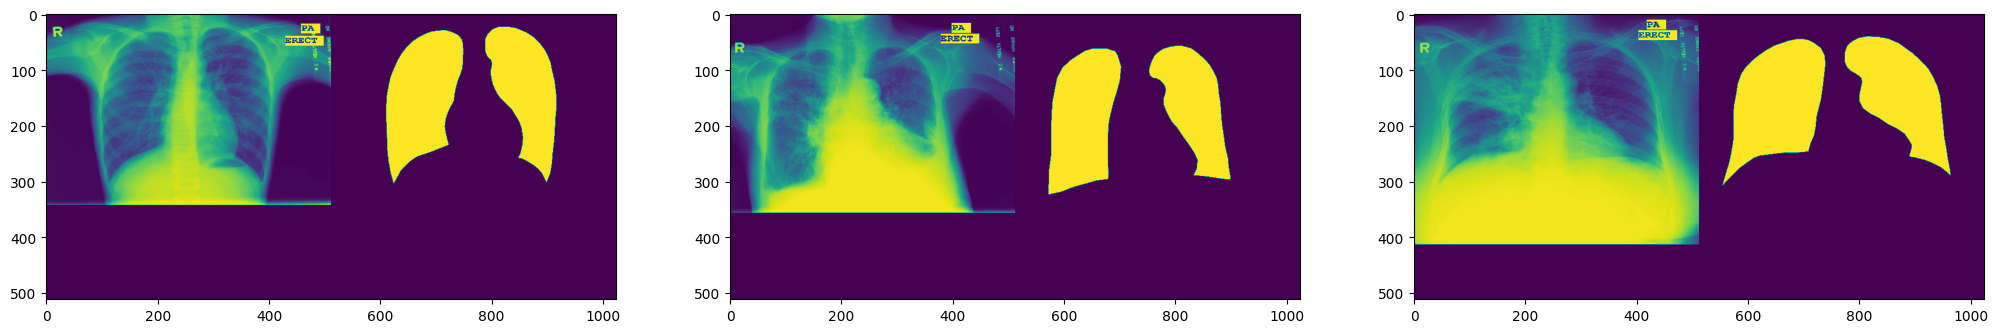

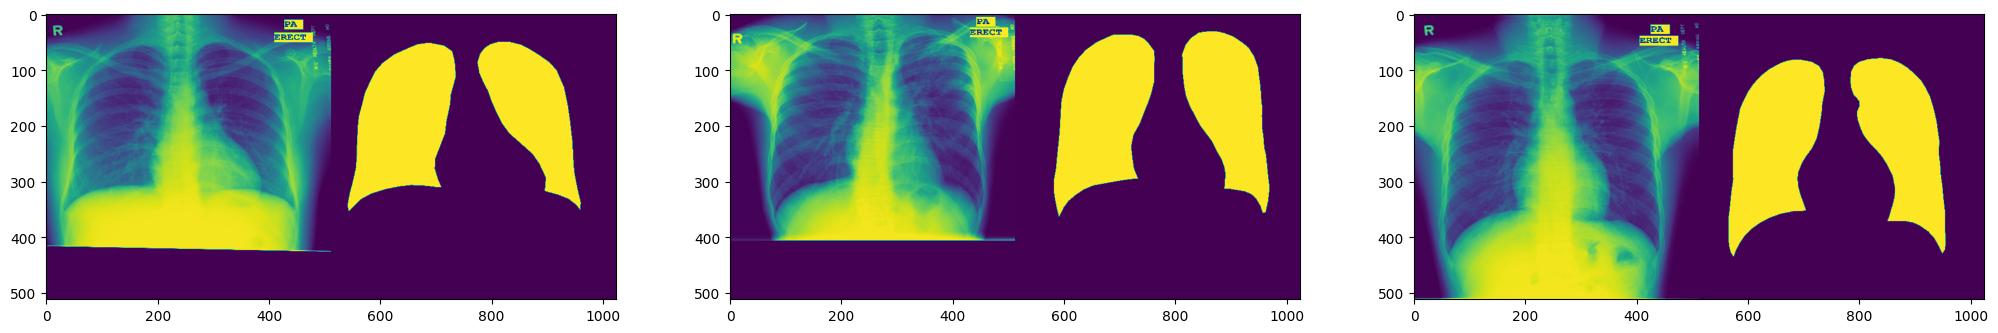

In [10]:
print("training set")
plotMask(X_train,y_train)
print("testing set")
plotMask(X_test,y_test)

In [11]:
X_train = np.array(X_train).reshape(len(X_train),dim,dim,1)
y_train = np.array(y_train).reshape(len(y_train),dim,dim,1)
X_test = np.array(X_test).reshape(len(X_test),dim,dim,1)
y_test = np.array(y_test).reshape(len(y_test),dim,dim,1)
assert X_train.shape == y_train.shape
assert X_test.shape == y_test.shape
images = np.concatenate((X_train,X_test),axis=0)
mask  = np.concatenate((y_train,y_test),axis=0)

In [12]:
from keras.models import *
from keras.layers import *
from keras.optimizers import *
from keras import backend as keras
from keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import ModelCheckpoint, LearningRateScheduler


def dice_coef(y_true, y_pred):
    y_true_f = keras.flatten(y_true)
    y_pred_f = keras.flatten(y_pred)
    intersection = keras.sum(y_true_f * y_pred_f)
    return (2. * intersection + 1) / (keras.sum(y_true_f) + keras.sum(y_pred_f) + 1)

def dice_coef_loss(y_true, y_pred):
    return -dice_coef(y_true, y_pred)

def unet(input_size=(256,256,1)):
    inputs = Input(input_size)

    # Encoder
    conv1 = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    conv1 = Conv2D(32, (3, 3), activation='relu', padding='same')(conv1)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = Conv2D(64, (3, 3), activation='relu', padding='same')(pool1)
    conv2 = Conv2D(64, (3, 3), activation='relu', padding='same')(conv2)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)

    conv3 = Conv2D(128, (3, 3), activation='relu', padding='same')(pool2)
    conv3 = Conv2D(128, (3, 3), activation='relu', padding='same')(conv3)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)

    conv4 = Conv2D(256, (3, 3), activation='relu', padding='same')(pool3)
    conv4 = Conv2D(256, (3, 3), activation='relu', padding='same')(conv4)
    pool4 = MaxPooling2D(pool_size=(2, 2))(conv4)

    # Decoder
    up5 = concatenate([Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(conv4), conv3], axis=3)
    conv5 = Conv2D(128, (3, 3), activation='relu', padding='same')(up5)
    conv5 = Conv2D(128, (3, 3), activation='relu', padding='same')(conv5)

    up6 = concatenate([Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(conv5), conv2], axis=3)
    conv6 = Conv2D(64, (3, 3), activation='relu', padding='same')(up6)
    conv6 = Conv2D(64, (3, 3), activation='relu', padding='same')(conv6)

    up7 = concatenate([Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(conv6), conv1], axis=3)
    conv7 = Conv2D(32, (3, 3), activation='relu', padding='same')(up7)
    conv7 = Conv2D(32, (3, 3), activation='relu', padding='same')(conv7)

    conv8 = Conv2D(1, (1, 1), activation='sigmoid')(conv7)  # Sigmoid activation for binary classification

    return Model(inputs=[inputs], outputs=[conv8])

#### Compile and train the Unet Model

In [13]:
model = unet(input_size=(512,512,1))
model.compile(optimizer=Adam(lr=1e-5), loss=dice_coef_loss,
                  metrics=[dice_coef, 'binary_accuracy'])
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 512, 512, 1)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 512, 512, 32)         320       ['input_1[0][0]']             
                                                                                                  
 conv2d_1 (Conv2D)           (None, 512, 512, 32)         9248      ['conv2d[0][0]']              
                                                                                                  
 max_pooling2d (MaxPooling2  (None, 256, 256, 32)         0         ['conv2d_1[0][0]']            
 D)                                                                                           

## Callbacks, Early Stopping and Reduced LR


In [14]:
from keras.callbacks import ModelCheckpoint, LearningRateScheduler, EarlyStopping, ReduceLROnPlateau
weight_path = "{}_weights.best.hdf5".format('cxr_reg')

checkpoint = ModelCheckpoint(weight_path, monitor='val_loss', verbose=1,
                             save_best_only=True, mode='min', save_weights_only=True)

reduceLROnPlat = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                   patience=3,
                                   verbose=1, mode='min', epsilon=0.0001, cooldown=2, min_lr=1e-6)
early = EarlyStopping(monitor="val_loss",
                      mode="min",
                      patience=10)  # Increased patience to 10
callbacks_list = [checkpoint, early, reduceLROnPlat]

In [15]:
from IPython.display import clear_output
from keras.optimizers import Adam
from sklearn.model_selection import train_test_split

model.compile(optimizer=Adam(lr=1e-5),  # Adjusted learning rate to 1e-5
              loss=[dice_coef_loss],
              metrics=[dice_coef, 'binary_accuracy'])

train_vol, validation_vol, train_seg, validation_seg = train_test_split((images - 127.0) / 127.0,
                                                                        (mask > 127).astype(np.float32),
                                                                        test_size=0.2,  # Adjusted test size to 0.2
                                                                        random_state=2000)

train_vol, test_vol, train_seg, test_seg = train_test_split(train_vol, train_seg,
                                                            test_size=0.25,
                                                            random_state=2000)

loss_history = model.fit(x=train_vol,
                         y=train_seg,
                         batch_size=16,
                         epochs=20,
                         validation_data=(test_vol, test_seg),
                         callbacks=callbacks_list)

Epoch 1/20
27/27 [==============================] - ETA: 0s - loss: -0.4578 - dice_coef: 0.4568 - binary_accuracy: 0.5542
Epoch 1: val_loss improved from inf to -0.54526, saving model to cxr_reg_weights.best.hdf5
27/27 [==============================] - 102s 2s/step - loss: -0.4578 - dice_coef: 0.4568 - binary_accuracy: 0.5542 - val_loss: -0.5453 - val_dice_coef: 0.5450 - val_binary_accuracy: 0.6431 - lr: 0.0010
Epoch 2/20
27/27 [==============================] - ETA: 0s - loss: -0.5465 - dice_coef: 0.5459 - binary_accuracy: 0.6494
Epoch 2: val_loss improved from -0.54526 to -0.55703, saving model to cxr_reg_weights.best.hdf5
27/27 [==============================] - 26s 963ms/step - loss: -0.5465 - dice_coef: 0.5459 - binary_accuracy: 0.6494 - val_loss: -0.5570 - val_dice_coef: 0.5567 - val_binary_accuracy: 0.6594 - lr: 0.0010
Epoch 3/20
27/27 [==============================] - ETA: 0s - loss: -0.5909 - dice_coef: 0.5922 - binary_accuracy: 0.6979
Epoch 3: val_loss improved from -0.5570

In [20]:
model.save('/content/drive/MyDrive/Major_Project_Pneumonia_Detection/models/seg_model1.h5')

## Plot the metric and evaluate

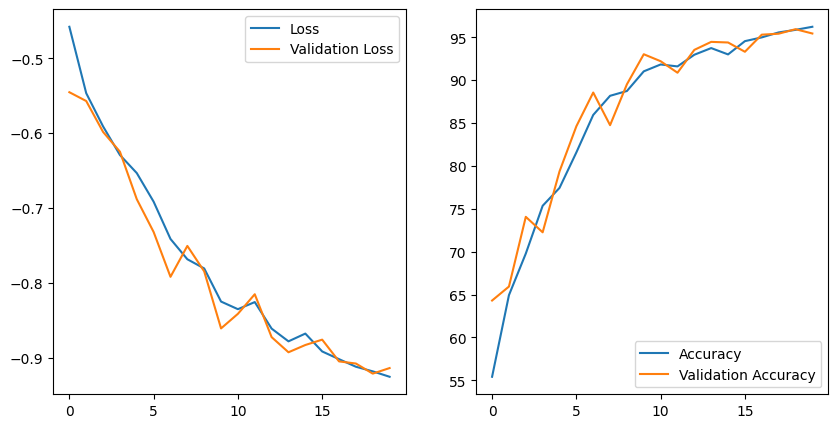

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (10, 5))
ax1.plot(loss_history.history['loss'], '-', label = 'Loss')
ax1.plot(loss_history.history['val_loss'], '-', label = 'Validation Loss')
ax1.legend()

ax2.plot(100*np.array(loss_history.history['binary_accuracy']), '-',
         label = 'Accuracy')
ax2.plot(100*np.array(loss_history.history['val_binary_accuracy']), '-',
         label = 'Validation Accuracy')
ax2.legend()

## Test the model

5/5 [==============================] - 25s 374ms/step


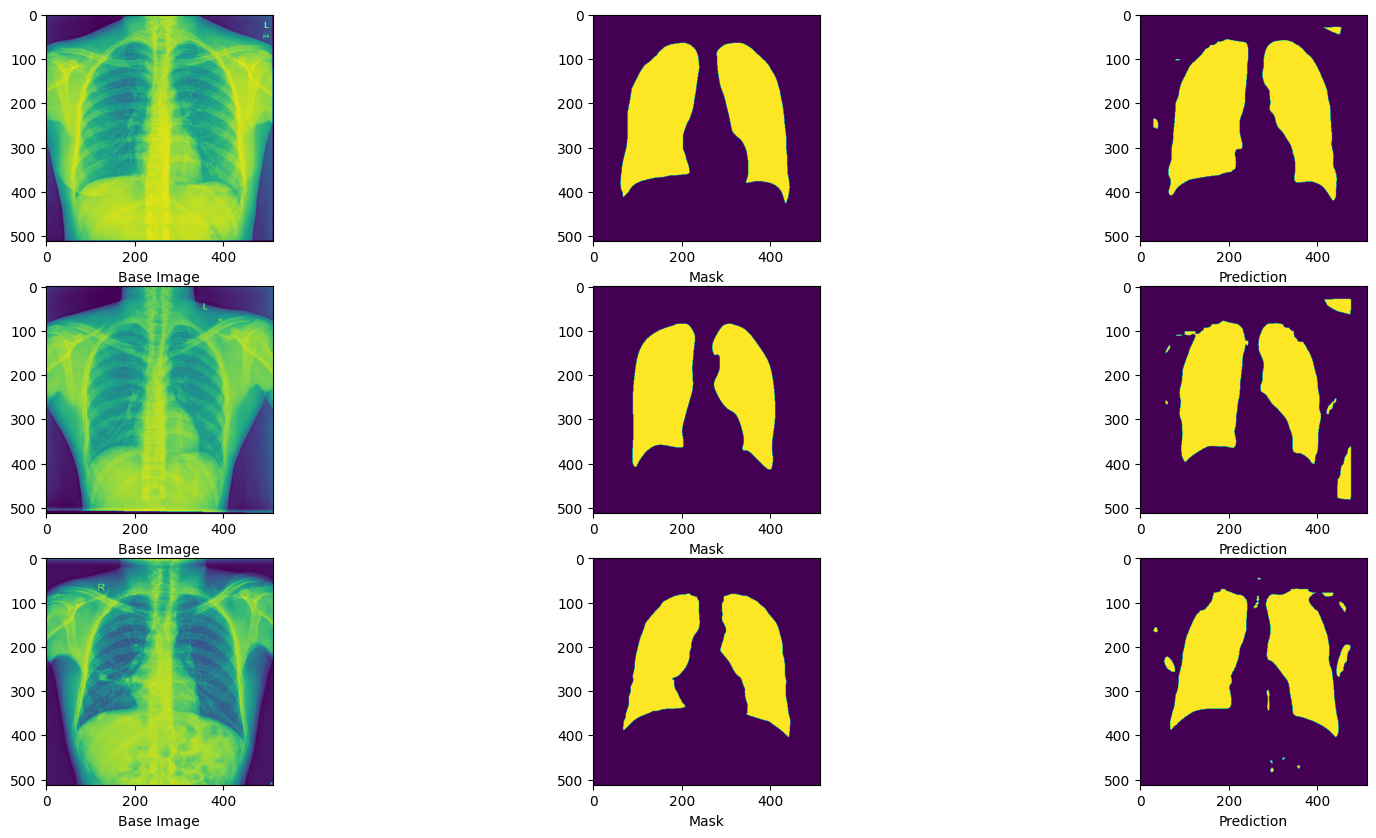

In [22]:
pred_candidates = np.random.randint(1,validation_vol.shape[0],10)
preds = model.predict(validation_vol)

plt.figure(figsize=(20,10))

for i in range(0,9,3):
    plt.subplot(3,3,i+1)

    plt.imshow(np.squeeze(validation_vol[pred_candidates[i]]))
    plt.xlabel("Base Image")


    plt.subplot(3,3,i+2)
    plt.imshow(np.squeeze(validation_seg[pred_candidates[i]]))
    plt.xlabel("Mask")

    plt.subplot(3,3,i+3)
    plt.imshow(np.squeeze(preds[pred_candidates[i]]))
    plt.xlabel("Prediction")

5/5 [==============================] - 2s 494ms/step


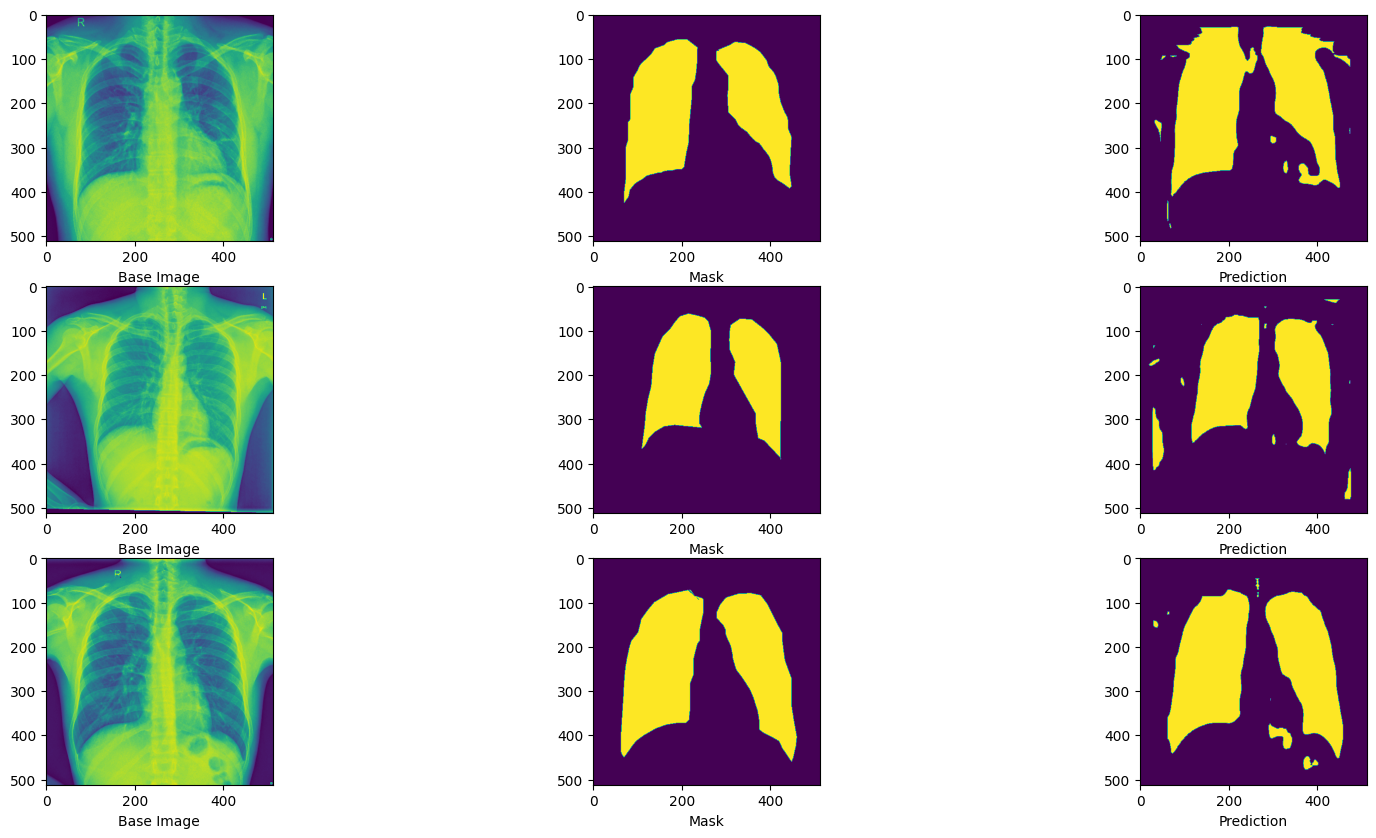

In [23]:
pred_candidates = np.random.randint(1,validation_vol.shape[0],10)
preds = model.predict(validation_vol)

plt.figure(figsize=(20,10))

for i in range(0,9,3):
    plt.subplot(3,3,i+1)

    plt.imshow(np.squeeze(validation_vol[pred_candidates[i]]))
    plt.xlabel("Base Image")


    plt.subplot(3,3,i+2)
    plt.imshow(np.squeeze(validation_seg[pred_candidates[i]]))
    plt.xlabel("Mask")

    plt.subplot(3,3,i+3)
    plt.imshow(np.squeeze(preds[pred_candidates[i]]))
    plt.xlabel("Prediction")

In [ ]:
pip install gradio

In [31]:
import gradio as gr

# Define your model loading and prediction functions
def load_model():
    # Load your model here
    model = unet(input_size=(512,512,1)) # Make sure to define the 'unet' function as per your existing code
    model.load_weights('cxr_reg_weights.best.hdf5')  # Load the weights
    return model

def predict_pneumonia(image):
    # Preprocess the image (resize, normalize, etc.)
    processed_image = preprocess_image(image)

    # Make prediction using your model
    prediction = model.predict(processed_image)

    # Convert prediction to text label
    label = "Pneumonia" if prediction > 0.5 else "No Pneumonia"

    return label

# Create a Gradio interface
iface = gr.Interface(fn=predict_pneumonia,
                      inputs="image",
                      outputs="text")

# Launch the interface
iface.launch()

Setting queue=True in a Colab notebook requires sharing enabled. Setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()


Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/gradio/queueing.py", line 527, in process_events
    response = await route_utils.call_process_api(
  File "/usr/local/lib/python3.10/dist-packages/gradio/route_utils.py", line 261, in call_process_api
    output = await app.get_blocks().process_api(
  File "/usr/local/lib/python3.10/dist-packages/gradio/blocks.py", line 1786, in process_api
    result = await self.call_function(
  File "/usr/local/lib/python3.10/dist-packages/gradio/blocks.py", line 1338, in call_function
    prediction = await anyio.to_thread.run_sync(
  File "/usr/local/lib/python3.10/dist-packages/anyio/to_thread.py", line 33, in run_sync
    return await get_asynclib().run_sync_in_worker_thread(
  File "/usr/local/lib/python3.10/dist-packages/anyio/_backends/_asyncio.py", line 877, in run_sync_in_worker_thread
    return await future
  File "/usr/local/lib/python3.10/dist-packages/anyio/_backends/_asyncio.py", line 807, in run
    r

Running on public URL: https://e190663a1d2f19de30.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)
